In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

In [2]:
def model(x, a, b, c):
    return a * x ** 2 + b * x + c

In [23]:
def norm_factory(a, b, c):
    def wrapped(y):
        x = y[0] + 1j * y[1]
        value = model(x, a, b, c)
        return np.sqrt(np.real(value) ** 2 + np.imag(value) ** 2)
    return wrapped

In [29]:
def root_factory(a, b, c):
    def wrapped(y):
        x = y[0] + 1j * y[1]
        value = model(x, a, b, c)
        return np.array([
            np.real(value),
            np.imag(value),
        ])
    return wrapped

In [34]:
p = (2 + 3j, 1 - 1j, 3 + 1j)

In [35]:
landscape = norm_factory(*p)

In [31]:
xlin = np.linspace(-2, 2, 200)
ylin = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(xlin, ylin)

In [32]:
Z = landscape([X, Y])

In [36]:
objective = root_factory(*p)

In [39]:
root1 = optimize.root(objective, [-1, -1])
root2 = optimize.root(objective, [+1, +1])

In [40]:
root1

 message: The solution converged.
 success: True
  status: 1
     fun: [ 6.302e-12  1.562e-12]
       x: [-2.668e-01 -7.138e-01]
  method: hybr
    nfev: 14
    fjac: [[-6.635e-01  7.481e-01]
           [-7.481e-01 -6.635e-01]]
       r: [-7.124e+00 -3.604e-01 -6.676e+00]
     qtf: [-8.136e-09 -1.553e-08]

In [41]:
root2

 message: The solution converged.
 success: True
  status: 1
     fun: [ 1.421e-14  1.776e-15]
       x: [ 3.438e-01  1.098e+00]
  method: hybr
    nfev: 14
    fjac: [[-6.054e-01  7.959e-01]
           [-7.959e-01 -6.054e-01]]
       r: [ 6.866e+00 -3.620e-02  6.922e+00]
     qtf: [ 3.365e-11  6.087e-11]

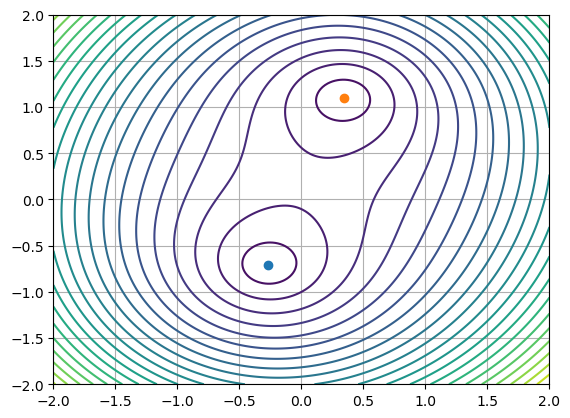

In [45]:
fig, axe = plt.subplots()
axe.contour(X, Y, Z, 30)
axe.scatter(*root1.x)
axe.scatter(*root2.x)
axe.grid()